# Activity Cliff 예측 파이프라인

구조가 **한 군데만 다른 두 분자**의 약효 차이(Δ)를 예측한다.
약효가 크게 차이 나는 쌍(|Δ| ≥ 1, **cliff**)을 잘 맞히는 것이 목표다.

In [1]:
import os, urllib.request
from multiprocessing import Pool
import numpy as np, pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFMCS, rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

DATA, PAIRS = 'data/moleculeace', 'data/pairs'
# 개발용: 작고 cliff 비율 높은 타깃 4개 (Ki 2 + EC50 2). 괜찮으면 30개로 늘린다
# CHEMBL2835_Ki는 쌍은 많지만 cliff 2%라 제외
DEV_TARGETS = ['CHEMBL1862_Ki', 'CHEMBL237_EC50', 'CHEMBL4616_EC50', 'CHEMBL2034_Ki']
USE_ALL_TARGETS = True  # True면 3번 셀에서 30개 전체로 바꾼다
SEED = 0
SEEDS = [0, 1, 2]       # 실행 간 편차를 재려면 시드가 여러 개여야 한다
SPLITS = ['train', 'val_easy', 'val_hard', 'test_easy', 'test_hard']
CLIFF = 1.0         # |Δ| >= 1 → cliff (MoleculeACE 기준, 10배)
VAL_FRAC = 0.2      # train 분자 중 validation 비율
SIM_MIN = 0.5       # ECFP4 Tanimoto 사전 필터 (MCS 통과 쌍의 99.5% 유지)
MAX_CHANGED = 10    # 한쪽에서 바뀐 원자 수 상한 (MMP 관례)
MCS_TIMEOUT = 1     # 초. 2초로 늘려도 통과 쌍 거의 같음
EXPAND_TRAIN = True # 학습 쌍을 유사도 조건만 만족하는 쌍 전부로 확대 (SQRL 방식). 평가 쌍은 그대로
N_JOBS = 64
os.makedirs(DATA, exist_ok=True); os.makedirs(PAIRS, exist_ok=True)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Noto Sans CJK JP', 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'axes.axisbelow': True})
# 검증된 기본 categorical 팔레트의 앞 네 칸 (파랑 / 주황 / 아쿠아 / 노랑)
C1, C2, C3, C4 = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
SURFACE, MUTED = 'white', '0.45'

def tidy(a):
    """축을 눈에 덜 띄게"""
    a.spines[['top', 'right']].set_visible(False)
    a.spines[['left', 'bottom']].set_color('0.7')
    a.tick_params(colors='0.35', length=3)

## 1. 데이터

MoleculeACE의 30개 단백질 타깃 데이터를 내려받는다.

In [2]:
URL = 'https://raw.githubusercontent.com/molML/MoleculeACE/main/MoleculeACE/Data/benchmark_data/'
TARGETS = ['CHEMBL1862_Ki', 'CHEMBL1871_Ki', 'CHEMBL2034_Ki', 'CHEMBL2047_EC50', 'CHEMBL204_Ki', 'CHEMBL2147_Ki',
           'CHEMBL214_Ki', 'CHEMBL218_EC50', 'CHEMBL219_Ki', 'CHEMBL228_Ki', 'CHEMBL231_Ki', 'CHEMBL233_Ki',
           'CHEMBL234_Ki', 'CHEMBL235_EC50', 'CHEMBL236_Ki', 'CHEMBL237_EC50', 'CHEMBL237_Ki', 'CHEMBL238_Ki',
           'CHEMBL239_EC50', 'CHEMBL244_Ki', 'CHEMBL262_Ki', 'CHEMBL264_Ki', 'CHEMBL2835_Ki', 'CHEMBL287_Ki',
           'CHEMBL2971_Ki', 'CHEMBL3979_EC50', 'CHEMBL4005_Ki', 'CHEMBL4203_Ki', 'CHEMBL4616_EC50', 'CHEMBL4792_Ki']
for t in TARGETS:
    if not os.path.exists(f'{DATA}/{t}.csv'):
        urllib.request.urlretrieve(f'{URL}{t}.csv', f'{DATA}/{t}.csv')
if USE_ALL_TARGETS:
    DEV_TARGETS = TARGETS
print(f'사용 타깃 {len(DEV_TARGETS)}개')

사용 타깃 30개


## 2. 분자 나누기

분자를 **학습 / 검증 / 평가**용으로 나눈다.
쌍의 난이도는 두 분자가 어디 속하는지로 정해진다.

- **easy**: 한 분자는 학습 때 본 분자
- **hard**: 두 분자 모두 처음 보는 분자

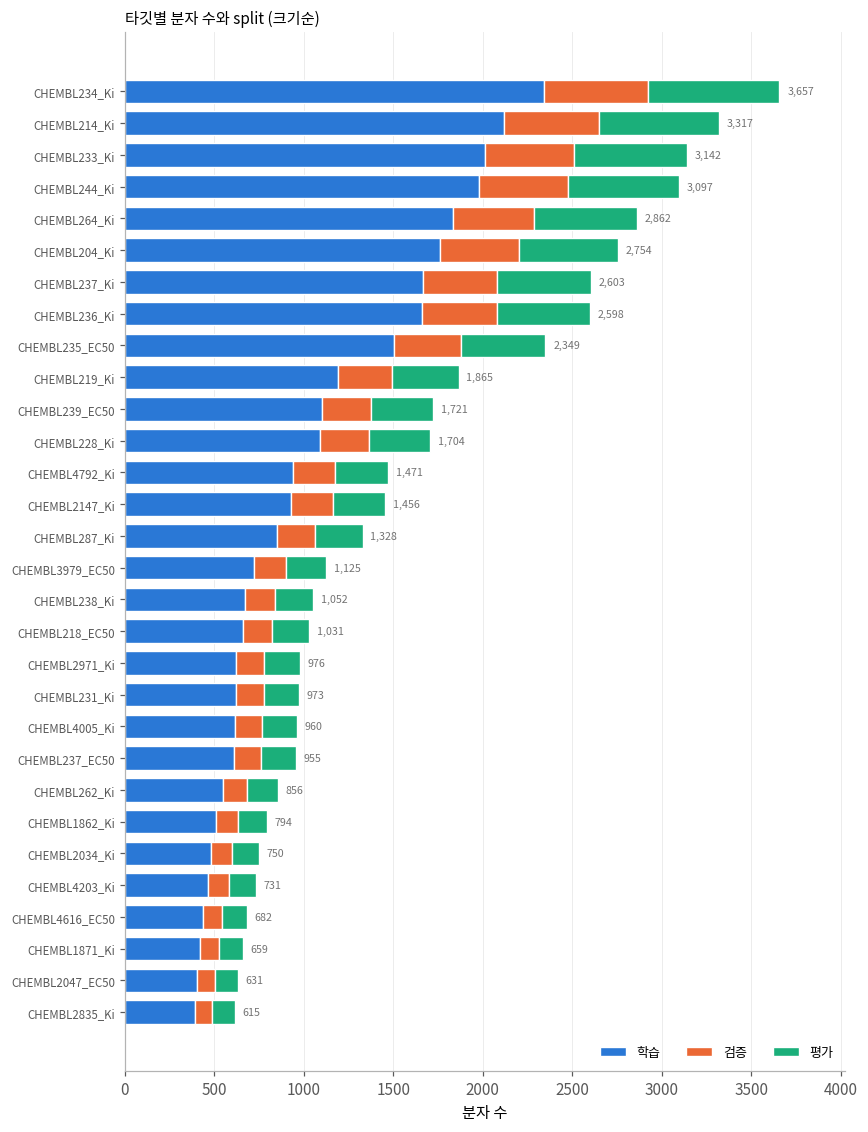

분자 48,714행 | train 31,144 (64%)  val 7,768 (16%)  test 9,802 (20%) | 타깃당 615~3,657개


In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)   # 30개 타깃이면 load가 수십 번 불린다
def load(target):
    df = pd.read_csv(f'{DATA}/{target}.csv').rename(columns={'y [pEC50/pKi]': 'p'})[['smiles', 'p', 'cliff_mol', 'split']]
    train = df.index[df.split == 'train']
    rng = np.random.default_rng(SEED)
    # ponytail: 단순 무작위 추출. val 결과가 흔들리면 cliff_mol 기준 층화 추출로 바꾼다
    df.loc[rng.choice(train, int(len(train) * VAL_FRAC), replace=False), 'split'] = 'val'
    return df

sp = pd.DataFrame({t: load(t).split.value_counts() for t in DEV_TARGETS}).T[['train', 'val', 'test']]
sp = sp.loc[sp.sum(1).sort_values().index]

fig, a_ = plt.subplots(figsize=(8, 0.30 * len(sp) + 1.4))
y, left = np.arange(len(sp)), np.zeros(len(sp))
for col, c, lbl in [('train', C1, '학습'), ('val', C2, '검증'), ('test', C3, '평가')]:
    a_.barh(y, sp[col], 0.74, left=left, color=c, label=lbl, zorder=2,
            edgecolor=SURFACE, linewidth=0.9)   # 흰 테두리로 구간을 떼어 놓는다
    left += sp[col].values
for i, v in enumerate(left):
    a_.text(v + left.max() * 0.012, i, f'{int(v):,}', va='center', fontsize=7, color=MUTED)

a_.set(yticks=y, xlabel='분자 수', xlim=(0, left.max() * 1.10))
a_.set_yticklabels(sp.index, fontsize=7.5)
a_.legend(fontsize=8.5, frameon=False, ncol=3, loc='lower right')
a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title('타깃별 분자 수와 split (크기순)', loc='left', fontsize=10)
fig.tight_layout(); plt.show()

tot = sp.sum()
print(f'분자 {int(tot.sum()):,}행 | ' + '  '.join(f'{k} {int(v):,} ({v/tot.sum():.0%})' for k, v in tot.items())
      + f' | 타깃당 {int(sp.sum(1).min()):,}~{int(sp.sum(1).max()):,}개')

## 3. "한 군데만 다른 쌍" 정하기

두 분자에서 **공통 부분을 찾고, 나머지를 바뀐 부분**으로 본다.
바뀐 부분이 **한 덩어리이고 작을 때만** 쌍으로 인정한다.
아래 그림에서 빨간 원자가 바뀐 부분이다.

In [4]:
def n_components(mol, atoms):
    left, n = set(atoms), 0
    while left:
        n += 1
        stack = [left.pop()]
        while stack:
            for nb in mol.GetAtomWithIdx(stack.pop()).GetNeighbors():
                if nb.GetIdx() in left:
                    left.remove(nb.GetIdx()); stack.append(nb.GetIdx())
    return n

def anchors(mol, changed, match):
    """바뀐 원자에 붙은 MCS 원자를 MCS 쿼리 내 순번으로 반환"""
    pos = {x: k for k, x in enumerate(match)}
    return {pos[nb.GetIdx()] for a in changed for nb in mol.GetAtomWithIdx(a).GetNeighbors() if nb.GetIdx() in pos}

def single_site(sa, sb):
    """한 곳만 다르면 (edit, atoms_a, atoms_b), 아니면 탈락 사유 문자열"""
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    if r.canceled:
        return 'timeout'
    q = Chem.MolFromSmarts(r.smartsString)
    ma = a.GetSubstructMatch(q)
    ca = [i for i in range(a.GetNumAtoms()) if i not in ma]
    # 대칭 분자는 매칭이 여러 개라 anchor 순번이 달라질 수 있어 B의 매칭을 모두 확인
    for mb in b.GetSubstructMatches(q, uniquify=False, maxMatches=1000):
        cb = [i for i in range(b.GetNumAtoms()) if i not in mb]
        if not ca and not cb:
            return 'identical_2d'
        if max(len(ca), len(cb)) > MAX_CHANGED:
            return 'too_big'
        if n_components(a, ca) > 1 or n_components(b, cb) > 1:
            continue
        if not ca or not cb or anchors(a, ca, ma) == anchors(b, cb, mb):
            return ('insert' if not ca else 'delete' if not cb else 'replace'), ca, cb
    return 'multi_site'

In [5]:
# 판정 규칙 확인
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1')[0] == 'replace'  # 치환기 교체
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(F)cc1')[0] == 'insert'      # H → F
assert single_site('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1')[0] == 'delete'      # F → H
assert single_site('Cc1ccccc1', 'Cc1ccncc1')[0] == 'replace'                     # 고리 원자 C → N
assert single_site('Fc1ccc(Cl)cc1', 'Nc1ccc(Br)cc1') == 'multi_site'             # 두 곳 변경
assert single_site('C[C@H](N)O', 'C[C@@H](N)O') == 'identical_2d'                # 입체만 다름
assert single_site('CC(=O)Nc1ccccc1', 'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1') == 'too_big'  # 13원자
print('판정 규칙 확인 완료')

판정 규칙 확인 완료


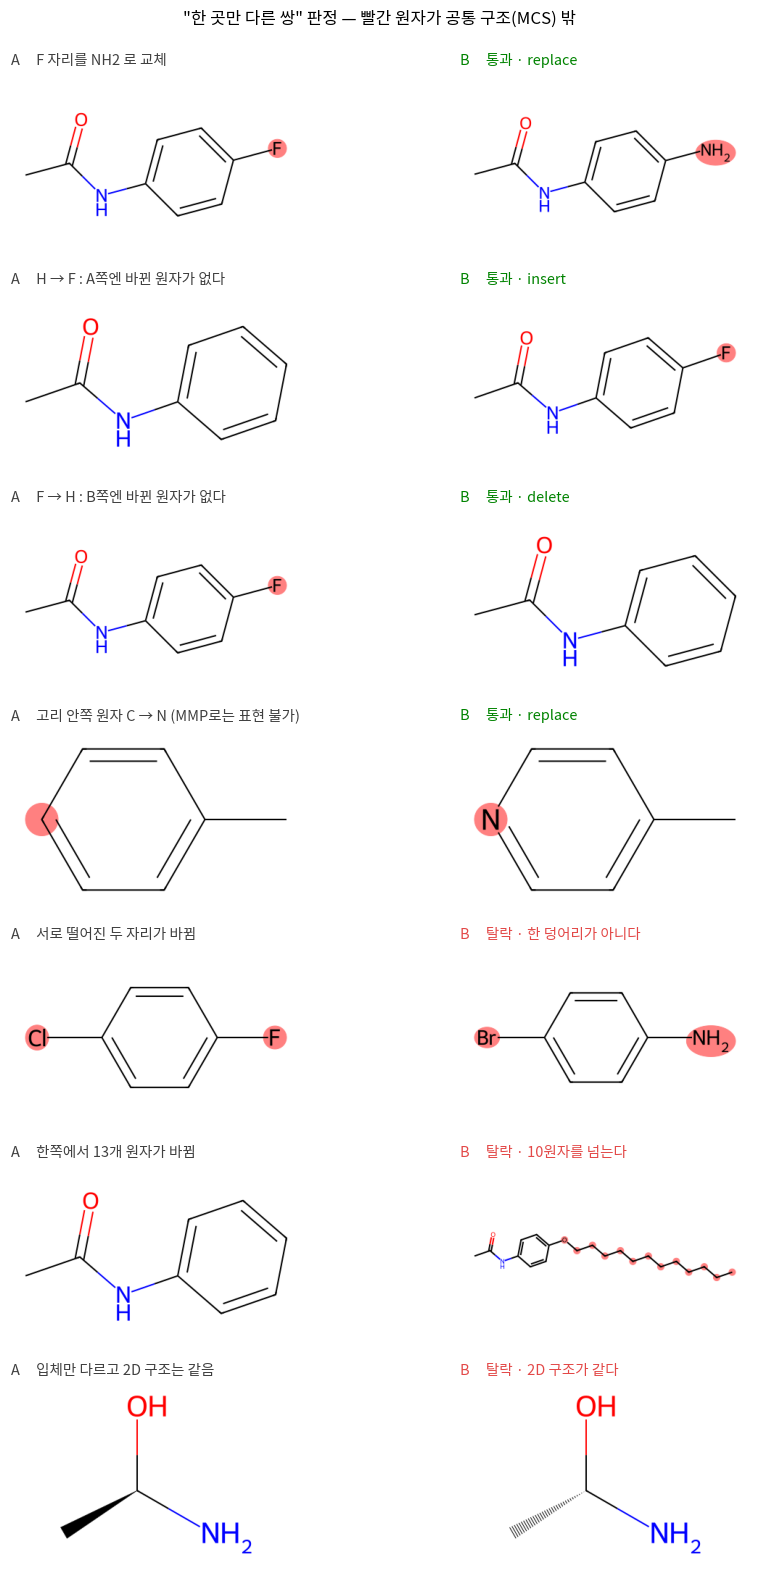

In [6]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

RULE_CASES = [
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccc(N)cc1', 'F 자리를 NH2 로 교체'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(F)cc1', 'H → F : A쪽엔 바뀐 원자가 없다'),
    ('CC(=O)Nc1ccc(F)cc1', 'CC(=O)Nc1ccccc1',    'F → H : B쪽엔 바뀐 원자가 없다'),
    ('Cc1ccccc1',          'Cc1ccncc1',          '고리 안쪽 원자 C → N (MMP로는 표현 불가)'),
    ('Fc1ccc(Cl)cc1',      'Nc1ccc(Br)cc1',      '서로 떨어진 두 자리가 바뀜'),
    ('CC(=O)Nc1ccccc1',    'CC(=O)Nc1ccc(OCCCCCCCCCCCC)cc1', '한쪽에서 13개 원자가 바뀜'),
    ('C[C@H](N)O',         'C[C@@H](N)O',        '입체만 다르고 2D 구조는 같음'),
]
VERDICT = {'replace': '통과 · replace', 'insert': '통과 · insert', 'delete': '통과 · delete',
           'multi_site': '탈락 · 한 덩어리가 아니다', 'too_big': f'탈락 · {MAX_CHANGED}원자를 넘는다',
           'identical_2d': '탈락 · 2D 구조가 같다'}
PASS, FAIL = '#008300', '#e34948'

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 MCS 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render(m, hl):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl)
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

fig, axes = plt.subplots(len(RULE_CASES), 2, figsize=(9.5, 2.05 * len(RULE_CASES)))
for (sa, sb, note), (ax_a, ax_b) in zip(RULE_CASES, axes):
    a, b = Chem.MolFromSmiles(sa), Chem.MolFromSmiles(sb)
    rdDepictor.Compute2DCoords(a)
    q, ca, cb = mcs_diff(a, b)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    res = single_site(sa, sb)
    key = res if isinstance(res, str) else res[0]
    ax_a.imshow(render(a, ca)); ax_b.imshow(render(b, cb))
    ax_a.set_title(f'A     {note}', loc='left', fontsize=9.5, color='0.25')
    ax_b.set_title(f'B     {VERDICT[key]}', loc='left', fontsize=9.5,
                   color=PASS if key in ('replace', 'insert', 'delete') else FAIL)
    for x in (ax_a, ax_b): x.axis('off')
fig.suptitle('"한 곳만 다른 쌍" 판정 — 빨간 원자가 공통 구조(MCS) 밖', y=0.995, fontsize=11)
fig.tight_layout(); plt.show()

## 4. 쌍 만들기

같은 타깃 안에서 서로 비슷한 분자끼리 짝을 짓고, 3번 규칙을 통과한 것만 남긴다.

In [7]:
FPGEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
PAIR_SPLIT = {('train', 'train'): 'train', ('train', 'val'): 'val_easy', ('val', 'val'): 'val_hard',
              ('test', 'train'): 'test_easy', ('test', 'test'): 'test_hard'}

def _job(args):
    i, j, sa, sb = args
    try:
        return i, j, single_site(sa, sb)
    except Exception:
        return i, j, 'error'

def make_pairs(target):
    path = f'{PAIRS}/{target}.pkl'
    if os.path.exists(path):
        cached = pd.read_pickle(path)
        return cached
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    cand = [(i, j) for i in range(len(df))
            for j, s in enumerate(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]), i + 1) if s >= SIM_MIN]
    cand = [(i, j) for i, j in cand if tuple(sorted((df.split[i], df.split[j]))) in PAIR_SPLIT]
    with Pool(N_JOBS) as pool:
        res = pool.map(_job, [(i, j, df.smiles[i], df.smiles[j]) for i, j in cand], chunksize=20)

    rows = []
    for i, j, r in res:
        if isinstance(r, str):
            continue
        edit, ca, cb = r
        a, b = Chem.MolFromSmiles(df.smiles[i]), Chem.MolFromSmiles(df.smiles[j])
        rows.append(dict(i=i, j=j, smiles_a=df.smiles[i], smiles_b=df.smiles[j], p_a=df.p[i], p_b=df.p[j],
                         delta=df.p[j] - df.p[i], edit=edit, atoms_a=ca, atoms_b=cb,
                         frag_a=Chem.MolFragmentToSmiles(a, ca) if ca else '',
                         frag_b=Chem.MolFragmentToSmiles(b, cb) if cb else '',
                         split=PAIR_SPLIT[tuple(sorted((df.split[i], df.split[j])))]))
    pairs = pd.DataFrame(rows)
    pairs['is_cliff'] = pairs.delta.abs() >= CLIFF
    pairs.to_pickle(path)
    return pairs

pairs = pd.concat([make_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True)
# 각 분자가 속한 split (쌍 split의 근거)
mol_split = {t: load(t).split for t in DEV_TARGETS}
pairs['split_a'] = [mol_split[t][i] for t, i in zip(pairs.target, pairs.i)]
pairs['split_b'] = [mol_split[t][j] for t, j in zip(pairs.target, pairs.j)]
print(f'쌍 {len(pairs):,}개  |  cliff {pairs.is_cliff.sum():,}개 ({pairs.is_cliff.mean():.1%})')

쌍 153,969개  |  cliff 33,989개 (22.1%)


## 4-1. 학습 쌍 늘리기

한 군데만 다른 쌍만으로는 학습 데이터가 부족하다.
그래서 **학습할 때는 비슷하기만 하면 전부** 쓰고, **평가는 그대로 한 군데만 다른 쌍**으로 한다.

In [8]:
def sim_pairs(target):
    """유사도 조건만 만족하는 쌍 전부 (모든 난이도). 공통 구조 계산이 없어 지문 비교만 하면 된다"""
    path = f'{PAIRS}/{target}_simall.pkl'
    if os.path.exists(path):
        return pd.read_pickle(path)
    df = load(target)
    fps = [FPGEN.GetFingerprint(Chem.MolFromSmiles(s)) for s in df.smiles]
    sp = df.split.values
    rows = []
    for i in range(len(df)):
        sims = np.array(DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:]))
        for j in np.where(sims >= SIM_MIN)[0] + i + 1:
            key = tuple(sorted((sp[i], sp[j])))
            if key in PAIR_SPLIT:
                rows.append(dict(i=int(i), j=int(j), delta=df.p[j] - df.p[i], split=PAIR_SPLIT[key]))
    out = pd.DataFrame(rows)
    out.to_pickle(path)
    return out

# 한 군데만 다른 쌍의 편집 정보를 유사 쌍 표에 옮겨 붙인다
info = pairs.set_index(['target', 'i', 'j'])[['edit', 'atoms_a', 'atoms_b']]
pairs_all = pd.concat([sim_pairs(t).assign(target=t) for t in DEV_TARGETS], ignore_index=True) \
              .join(info, on=['target', 'i', 'j'])
assert pairs_all.edit.notna().sum() == len(info), '한 군데만 다른 쌍은 모두 유사 쌍 안에 있어야 한다'
pairs_all['edit'] = pairs_all.edit.fillna('multi')
pairs_all[['atoms_a', 'atoms_b']] = pairs_all[['atoms_a', 'atoms_b']].map(lambda v: v if isinstance(v, list) else [])
pairs_all['is_cliff'] = pairs_all.delta.abs() >= CLIFF

# 두 가지 설정. 학습과 평가를 같은 종류의 쌍으로 맞춘다
PAIRSETS = {'single': pairs, 'all': pairs_all}

summary = pd.DataFrame({
    '한 군데만 다른 쌍': {'학습': int((pairs.split == 'train').sum()),
                   '평가(val+test)': int((pairs.split != 'train').sum()),
                   'cliff 비율': f'{pairs.is_cliff.mean():.1%}'},
    '유사 쌍 전부':     {'학습': int((pairs_all.split == 'train').sum()),
                   '평가(val+test)': int((pairs_all.split != 'train').sum()),
                   'cliff 비율': f'{pairs_all.is_cliff.mean():.1%}'}}).T
summary['배수'] = [1.0, round(len(pairs_all) / len(pairs), 1)]
summary

,학습,평가(val+test),cliff 비율,배수
한 군데만 다른 쌍,67509,86460,22.1%,1.0
유사 쌍 전부,349565,451868,27.7%,5.2


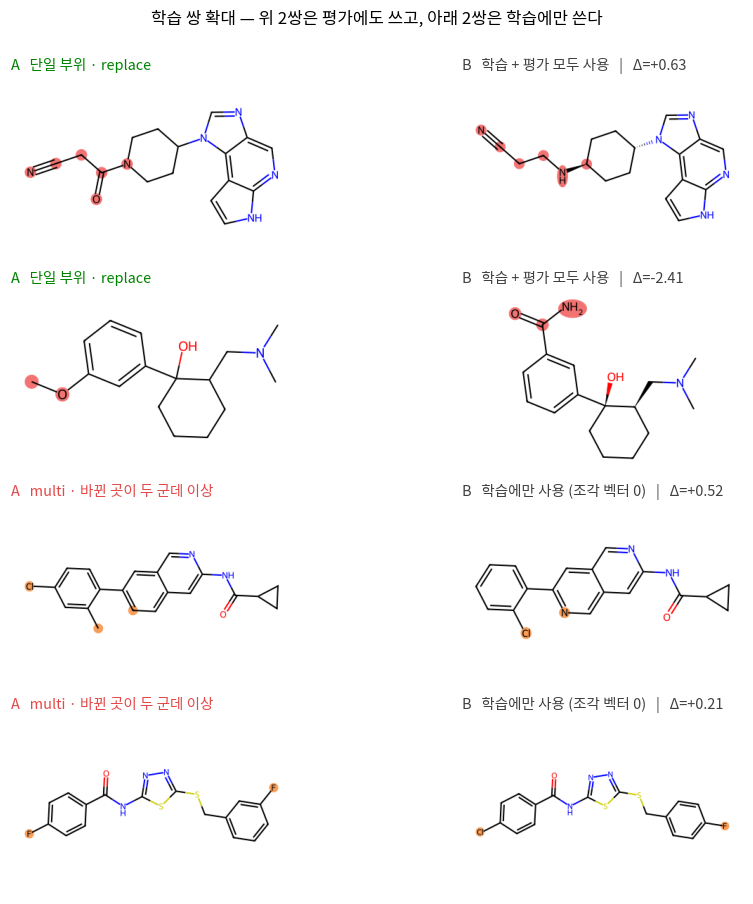

In [9]:
import io
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

def _smi(t, k): return load(t).smiles[k]
def _nat(t, k): return Chem.MolFromSmiles(_smi(t, k)).GetNumAtoms()

def mcs_diff(a, b):
    """판정 통과 여부와 무관하게 공통 구조 밖 원자를 구한다 (그림 전용)"""
    r = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                       bondCompare=rdFMCS.BondCompare.CompareOrder,
                       ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
    q = Chem.MolFromSmarts(r.smartsString)
    ma, mb = a.GetSubstructMatch(q), b.GetSubstructMatch(q)
    return q, [i for i in range(a.GetNumAtoms()) if i not in ma], [i for i in range(b.GetNumAtoms()) if i not in mb]

def render_mol(m, hl, color):
    """RDKit으로 분자만 그린다. 글자는 matplotlib이 얹는다 (RDKit 폰트에 한글이 없다)"""
    d = rdMolDraw2D.MolDraw2DCairo(400, 250)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl, highlightAtomColors={i: color for i in hl})
    d.FinishDrawing()
    return plt.imread(io.BytesIO(d.GetDrawingText()))

def _pick(sub, n, seed, want_multi):
    """작고 보기 좋은 예시만 고른다. multi는 바뀐 곳이 실제로 두 군데 이상인 것"""
    out = []
    for r in sub.sample(min(len(sub), 600), random_state=seed).itertuples():
        if max(_nat(r.target, r.i), _nat(r.target, r.j)) > 24:
            continue
        a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
        _, ca, cb = mcs_diff(a, b)
        if not ca or not cb or max(len(ca), len(cb)) > 6:
            continue
        if (max(n_components(a, ca), n_components(b, cb)) >= 2) != want_multi:
            continue
        out.append(r)
        if len(out) == n:
            break
    return out

RED, ORANGE = (0.95, 0.45, 0.45), (0.97, 0.62, 0.35)
_tr = pairs_all[pairs_all.split == 'train']
rows = ([(r, 'single') for r in _pick(_tr[_tr.edit != 'multi'], 2, 1, False)]
        + [(r, 'multi') for r in _pick(_tr[_tr.edit == 'multi'], 2, 5, True)])

fig, axes = plt.subplots(len(rows), 2, figsize=(9.5, 2.05 * len(rows)))
for (r, kind), (ax_a, ax_b) in zip(rows, axes):
    a, b = Chem.MolFromSmiles(_smi(r.target, r.i)), Chem.MolFromSmiles(_smi(r.target, r.j))
    rdDepictor.Compute2DCoords(a)
    q, ca, cb = mcs_diff(a, b)
    rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=q, acceptFailure=True)
    col = RED if kind == 'single' else ORANGE
    ax_a.imshow(render_mol(a, ca, col)); ax_b.imshow(render_mol(b, cb, col))
    if kind == 'single':
        ax_a.set_title(f'A   단일 부위 · {r.edit}', loc='left', fontsize=9.5, color='#008300')
        ax_b.set_title(f'B   학습 + 평가 모두 사용   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    else:
        ax_a.set_title('A   multi · 바뀐 곳이 두 군데 이상', loc='left', fontsize=9.5, color='#e34948')
        ax_b.set_title(f'B   학습에만 사용 (조각 벡터 0)   |   Δ={r.delta:+.2f}', loc='left', fontsize=9.5, color='0.25')
    for x in (ax_a, ax_b):
        x.axis('off')
fig.suptitle('학습 쌍 확대 — 위 2쌍은 평가에도 쓰고, 아래 2쌍은 학습에만 쓴다', y=0.997, fontsize=11)
fig.tight_layout(); plt.show()

## 5. 쌍 살펴보기

만들어진 쌍의 개수와 cliff 비율, 그리고 실제 예시를 본다.
cliff 쌍을 일부러 골라 넣지 않았다 — 쌍을 먼저 만들고 약효 차이는 나중에 확인했다.

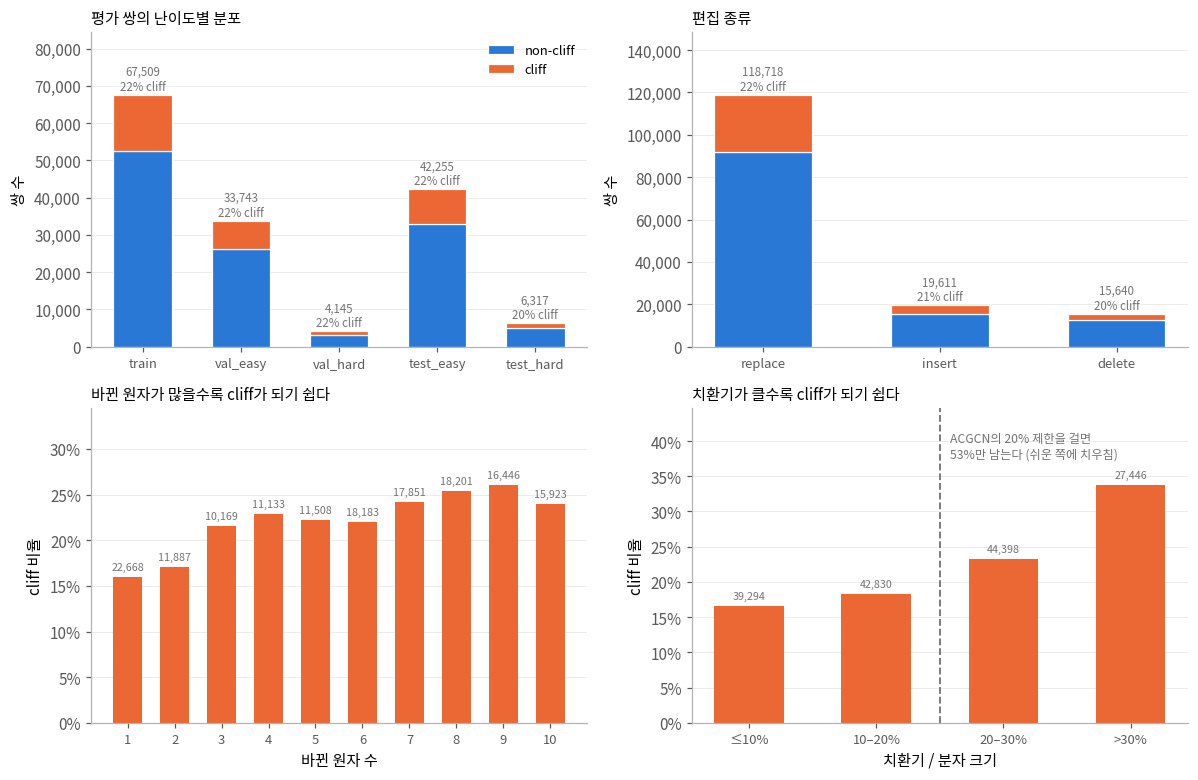

In [10]:
# 바뀐 원자 수와 "치환기 / 분자" 크기 비율 (ACGCN은 20% 이하인 쌍만 썼다)
n_heavy = {(t, k): Chem.MolFromSmiles(s).GetNumAtoms() for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
pairs['n_changed'] = pairs[['atoms_a', 'atoms_b']].map(len).max(axis=1)
pairs['size_ratio'] = pairs.n_changed / [min(n_heavy[t, i], n_heavy[t, j])
                                         for t, i, j in zip(pairs.target, pairs.i, pairs.j)]

fig, ax = plt.subplots(2, 2, figsize=(11, 7.2))
thousands = lambda v, _: f'{int(v):,}'

def stacked(a_, idx, nc, cl, width=0.6):
    x = np.arange(len(idx))
    a_.bar(x, nc, width, color=C1, label='non-cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    a_.bar(x, cl, width, bottom=nc, color=C2, label='cliff', zorder=2, edgecolor=SURFACE, linewidth=0.8)
    for i, (n, c) in enumerate(zip(nc, cl)):
        a_.text(i, n + c + (nc + cl).max() * 0.02, f'{n + c:,}\n{c / (n + c):.0%} cliff',
                ha='center', fontsize=7.5, color=MUTED)
    a_.set(xticks=x, ylabel='쌍 수', ylim=(0, (nc + cl).max() * 1.25))
    a_.set_xticklabels(idx, fontsize=8.5)
    a_.yaxis.set_major_formatter(thousands)

d = pairs.groupby(['split', 'is_cliff']).size().unstack(fill_value=0).reindex(SPLITS)
stacked(ax[0, 0], SPLITS, d[False].values, d[True].values)
ax[0, 0].legend(fontsize=8.5, frameon=False)
ax[0, 0].set_title('평가 쌍의 난이도별 분포', loc='left', fontsize=10)

e = pairs.groupby(['edit', 'is_cliff']).size().unstack(fill_value=0).sort_values(True, ascending=False)
stacked(ax[0, 1], e.index, e[False].values, e[True].values, 0.55)
ax[0, 1].set_title('편집 종류', loc='left', fontsize=10)

def ratio_bars(a_, g, xlabel, note=None, width=0.6):
    x = np.arange(len(g))
    a_.bar(x, g['mean'], width, color=C2, zorder=2)
    for i, (_, r) in enumerate(g.iterrows()):
        a_.text(i, r['mean'] + g['mean'].max() * 0.03, f'{int(r["size"]):,}', ha='center', fontsize=7, color=MUTED)
    a_.set(xticks=x, xlabel=xlabel, ylabel='cliff 비율', ylim=(0, g['mean'].max() * 1.32))
    a_.set_xticklabels(g.index, fontsize=8.5)
    a_.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')

ratio_bars(ax[1, 0], pairs.groupby('n_changed').is_cliff.agg(['size', 'mean']), '바뀐 원자 수')
ax[1, 0].set_title('바뀐 원자가 많을수록 cliff가 되기 쉽다', loc='left', fontsize=10)

rb = pd.cut(pairs.size_ratio, [0, 0.1, 0.2, 0.3, 1.0], labels=['≤10%', '10–20%', '20–30%', '>30%'])
g = pairs.groupby(rb, observed=True).is_cliff.agg(['size', 'mean'])
ratio_bars(ax[1, 1], g, '치환기 / 분자 크기', width=0.55)
ax[1, 1].axvline(1.5, color=MUTED, ls='--', lw=1.2)
ax[1, 1].text(1.58, g['mean'].max() * 1.22, f'ACGCN의 20% 제한을 걸면\n{(pairs.size_ratio <= 0.2).mean():.0%}만 남는다 (쉬운 쪽에 치우침)',
              fontsize=8, color=MUTED, va='top')
ax[1, 1].set_title('치환기가 클수록 cliff가 되기 쉽다', loc='left', fontsize=10)

for a_ in ax.ravel():
    tidy(a_); a_.grid(axis='x', visible=False)
fig.tight_layout(); plt.show()

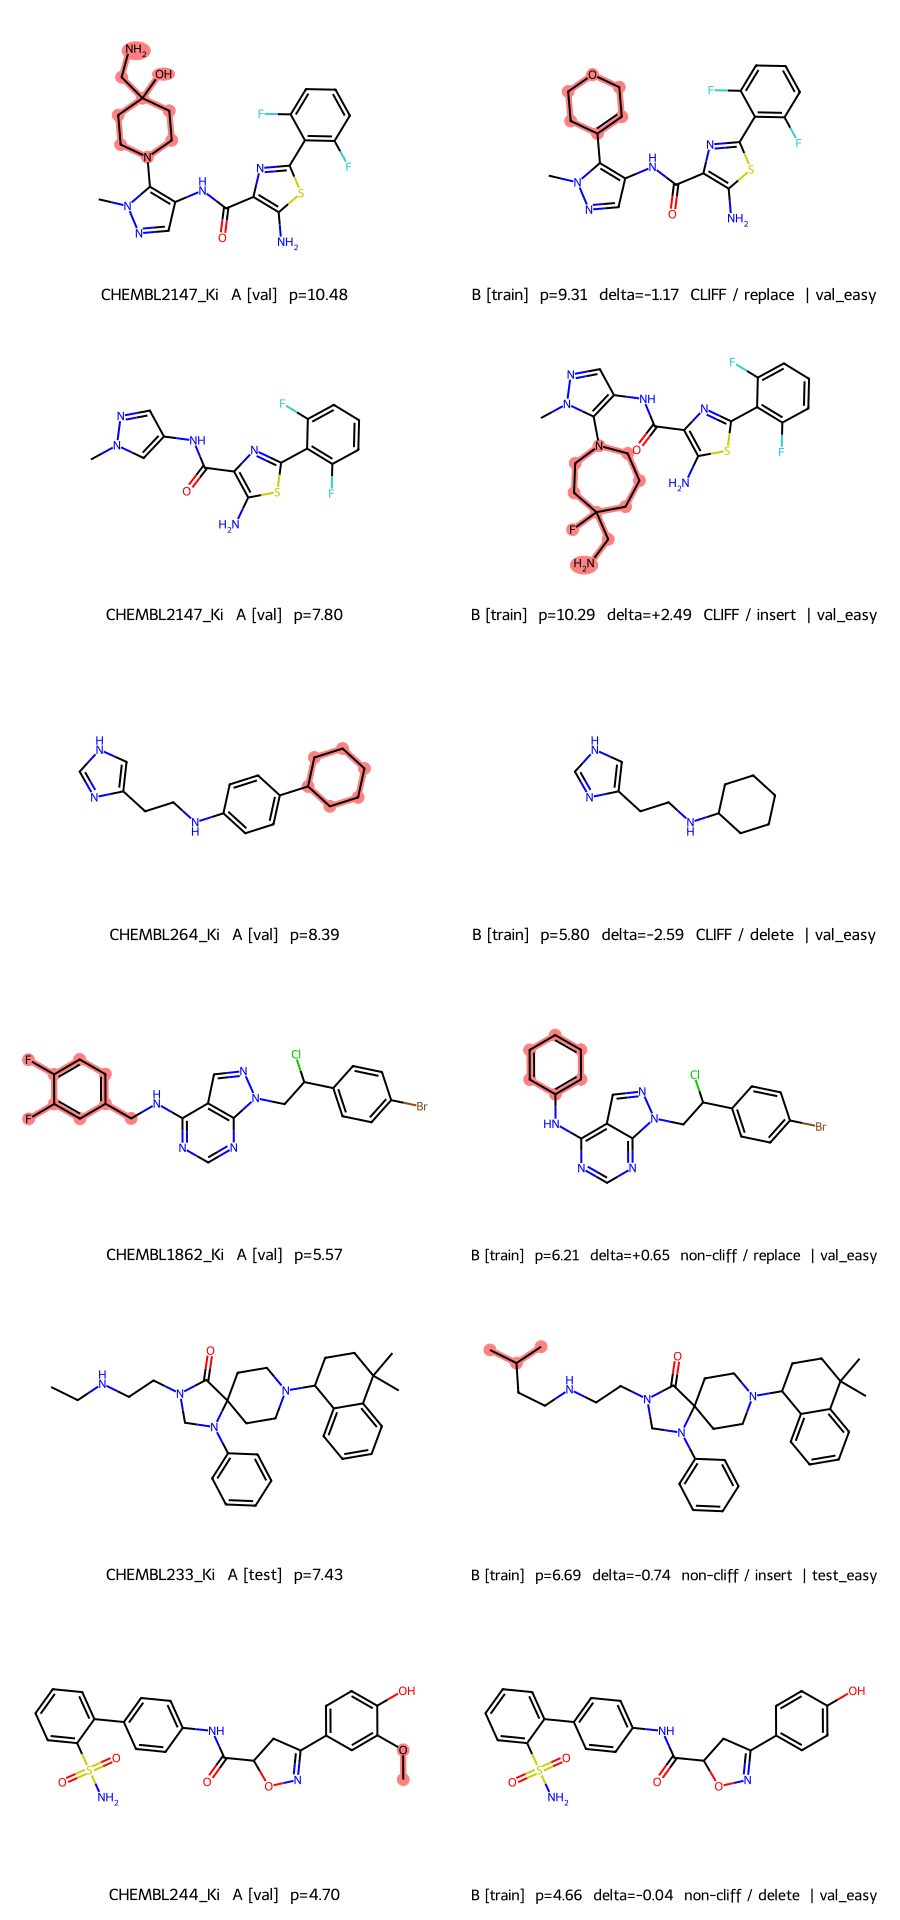

In [11]:
from rdkit.Chem import Draw, rdDepictor

def draw_pairs(rows):
    mols, highlights, legends = [], [], []
    for r in rows.itertuples():
        a, b = Chem.MolFromSmiles(r.smiles_a), Chem.MolFromSmiles(r.smiles_b)
        rdDepictor.Compute2DCoords(a)
        mcs = rdFMCS.FindMCS([a, b], atomCompare=rdFMCS.AtomCompare.CompareElements,
                             bondCompare=rdFMCS.BondCompare.CompareOrder, ringMatchesRingOnly=True, timeout=MCS_TIMEOUT)
        rdDepictor.GenerateDepictionMatching2DStructure(b, a, refPatt=Chem.MolFromSmarts(mcs.smartsString), acceptFailure=True)
        mols += [a, b]
        highlights += [r.atoms_a, r.atoms_b]
        legends += [f'{r.target}  A [{r.split_a}]  p={r.p_a:.2f}',
                    f'B [{r.split_b}]  p={r.p_b:.2f}  delta={r.delta:+.2f}  {"CLIFF" if r.is_cliff else "non-cliff"} / {r.edit}  | {r.split}']
    return Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(450, 320), highlightAtomLists=highlights, legends=legends)

sample = pairs.groupby(['is_cliff', 'edit']).sample(1, random_state=SEED).sort_values(['is_cliff', 'edit'], ascending=False)
draw_pairs(sample)

## 6. easy / hard 예시

같은 분자라도 **짝이 누구냐에 따라** easy가 되기도, hard가 되기도 한다.

기준 분자 C = CHEMBL239_EC50:184


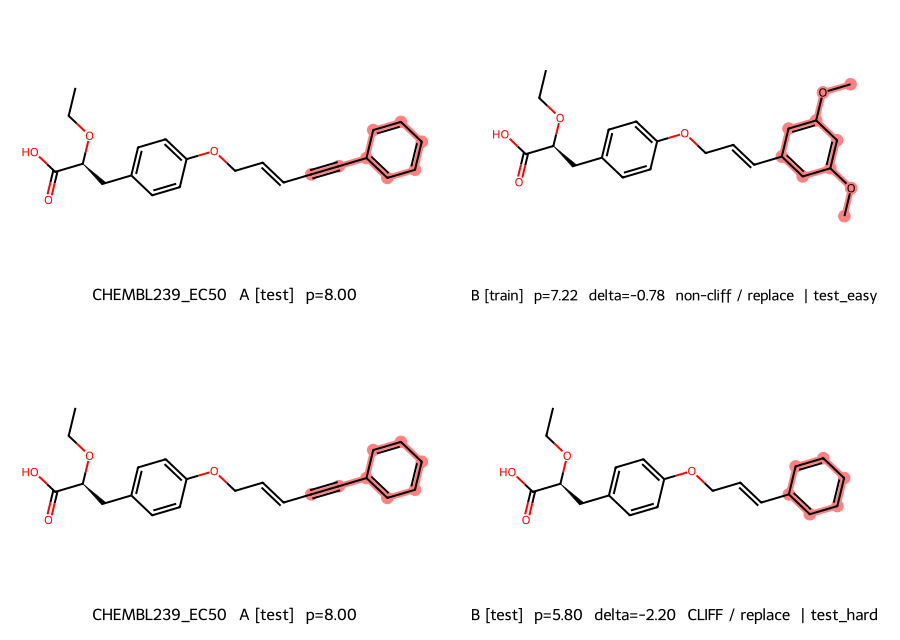

In [12]:
# 쌍마다 test 분자를 기준 분자(center)로 펼친 뒤, easy 쌍과 hard 쌍을 둘 다 가진 test 분자 하나 선택
long = pd.concat([pairs[pairs[s] == 'test'].assign(center=lambda x: x.target + ':' + x[m].astype(str))
                  for m, s in [('i', 'split_a'), ('j', 'split_b')]])
has_both = long.groupby('center').split.agg(lambda s: {'test_easy', 'test_hard'} <= set(s))
center = has_both[has_both].sample(1, random_state=SEED).index[0]
print('기준 분자 C =', center)
draw_pairs(long[long.center == center].groupby('split').sample(1, random_state=SEED).sort_values('split'))

In [13]:
# 분자 split 조합이 쌍 난이도로 제대로 이어졌는지 확인 (val–test 조합은 없어야 한다)
assert set(zip(pairs.split_a, pairs.split_b)) <= {(a, b) for a, b in PAIR_SPLIT} | {(b, a) for a, b in PAIR_SPLIT}
assert not pairs.split.isna().any()
print('쌍 난이도 배정 확인 완료')

쌍 난이도 배정 확인 완료


## 7. 비교 대상 (SVR)

기존 방식: 분자 하나씩 약효를 예측한 뒤 **두 값을 빼서** 차이를 구한다.
**항상 0이라고 답하는 기준**도 함께 둔다.

In [14]:
from sklearn.svm import SVR

SVR_C = [1, 10, 100, 1000]

def ecfp(smiles):
    return np.array([FPGEN.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in smiles], dtype=np.float32)

def tanimoto(X, Y):
    inter = X @ Y.T
    return inter / (X.sum(1)[:, None] + Y.sum(1)[None, :] - inter)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def svr_predict(target):
    """train 분자로 학습, val로 C 선택 → 모든 분자의 예측값"""
    df = load(target)
    X = ecfp(df.smiles)
    tr, va = (df.split == 'train').values, (df.split == 'val').values
    K = tanimoto(X, X[tr])
    fit = lambda C: SVR(kernel='precomputed', C=C).fit(K[tr], df.p[tr])
    val_rmse = {C: rmse(fit(C).predict(K[va]), df.p[va]) for C in SVR_C}
    best = min(val_rmse, key=val_rmse.get)
    return df.assign(pred=fit(best).predict(K)), best

mol_pred, rows = {}, []
for t in DEV_TARGETS:
    d, C = svr_predict(t)
    mol_pred[t] = d.pred
    te = d[d.split == 'test']
    rows.append(dict(target=t, C=C, test_rmse=rmse(te.pred, te.p), test_rmse_cliff_mol=rmse(te.pred[te.cliff_mol == 1], te.p[te.cliff_mol == 1])))
for _p in PAIRSETS.values():   # 두 설정의 쌍 모두에 붙인다
    _p['pred_svr'] = [mol_pred[t][j] - mol_pred[t][i] for t, i, j in zip(_p.target, _p.i, _p.j)]
    _p['pred_zero'] = 0.0
svr_mol = pd.DataFrame(rows)
print(f'타깃 {len(svr_mol)}개 학습 완료  |  분자 단위 test RMSE 중앙값 {svr_mol.test_rmse.median():.3f}')

타깃 30개 학습 완료  |  분자 단위 test RMSE 중앙값 0.694


### 평가 방법

난이도(easy / hard) × cliff 여부로 나눠서 오차(RMSE)를 본다. 낮을수록 좋다.

In [15]:
def rmse_table(df, col, index='split'):
    se = df.assign(se=(df[col] - df.delta) ** 2)
    t = se.pivot_table(index=index, columns='is_cliff', values='se', aggfunc='mean').rename(columns={False: 'non-cliff', True: 'cliff'})
    t['all'] = se.groupby(index).se.mean()
    return t[['cliff', 'non-cliff', 'all']] ** 0.5

pd.concat({m: rmse_table(pairs, f'pred_{m}').loc[SPLITS] for m in ['zero', 'svr']}, axis=1).round(3)

zero                     svr                 
is_cliff   cliff non-cliff    all  cliff non-cliff    all
split                                                    
train      1.744     0.462  0.916  0.423     0.167  0.248
val_easy   1.752     0.464  0.917  0.946     0.446  0.593
val_hard   1.813     0.465  0.950  1.321     0.519  0.774
test_easy  1.720     0.465  0.910  0.928     0.447  0.590
test_hard  1.715     0.470  0.880  1.256     0.524  0.734

## 8. 분자를 그래프로 바꾸기

원자는 점, 결합은 선으로 바꿔 모델에 넣는다. 나중에 3D 입력으로 바꿀 자리다.

In [16]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from rdkit.Chem.rdchem import HybridizationType as H, BondType as B

ELEMENTS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'B', 'Si', 'Se']
HYBRID = [H.SP, H.SP2, H.SP3, H.SP3D, H.SP3D2]
BONDS = [B.SINGLE, B.DOUBLE, B.TRIPLE, B.AROMATIC]
EDITS = ['replace', 'insert', 'delete', 'multi']  # multi = 단일 부위가 아닌 학습 전용 쌍 (조각 없음)
FLIP = {'replace': 'replace', 'insert': 'delete', 'delete': 'insert', 'multi': 'multi'}

def onehot(x, choices):
    return [float(x == c) for c in choices] + [float(x not in choices)]

def atom_features(a):
    return (onehot(a.GetSymbol(), ELEMENTS) + onehot(a.GetDegree(), [0, 1, 2, 3, 4, 5]) + onehot(a.GetFormalCharge(), [-1, 0, 1])
            + onehot(a.GetTotalNumHs(), [0, 1, 2, 3]) + onehot(a.GetHybridization(), HYBRID) + [float(a.GetIsAromatic()), float(a.IsInRing())])

def graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    src, dst, edge = [], [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        f = onehot(b.GetBondType(), BONDS) + [float(b.GetIsConjugated())]
        src += [i, j]; dst += [j, i]; edge += [f, f]
    return Data(x=torch.tensor([atom_features(a) for a in mol.GetAtoms()]),
                edge_index=torch.tensor([src, dst], dtype=torch.long).reshape(2, -1),
                edge_attr=torch.tensor(edge).reshape(-1, len(BONDS) + 2))

graphs = {(t, k): graph(s) for t in DEV_TARGETS for k, s in enumerate(load(t).smiles)}
N_ATOM, N_BOND = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0))), len(BONDS) + 2

def with_mask(g, atoms):
    mask = torch.zeros(g.num_nodes, dtype=torch.bool)
    mask[torch.tensor(atoms, dtype=torch.long)] = True  # atoms가 비면(multi 쌍) 전부 False → f = 0 벡터
    return Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, mask=mask)

def samples(df, both_directions=False, reverse=False):
    """reverse=True면 (B, A, −Δ)만 만든다. 양방향 평균 예측에 쓴다"""
    out = []
    for r in df.itertuples():
        ga, gb = with_mask(graphs[r.target, r.i], r.atoms_a), with_mask(graphs[r.target, r.j], r.atoms_b)
        t = DEV_TARGETS.index(r.target)
        fwd = (ga, gb, EDITS.index(r.edit), t, r.delta)
        rev = (gb, ga, EDITS.index(FLIP[r.edit]), t, -r.delta)
        out += [fwd, rev] if both_directions else [rev] if reverse else [fwd]
    return out

def collate(batch):
    ga, gb, edit, tgt, y = zip(*batch)
    return (Batch.from_data_list(ga), Batch.from_data_list(gb),
            torch.tensor(edit), torch.tensor(tgt), torch.tensor(y, dtype=torch.float32))

ga, gb, edit, tgt, y = collate(samples(pairs.head(2)))
print('원자 특징', N_ATOM, '| 결합 특징', N_BOND, '| 타깃', len(DEV_TARGETS),
      '| 배치 A 노드', ga.num_nodes, '| mask 원자', int(ga.mask.sum()), '| edit', edit.tolist())

/home/bising0922/micromamba/envs/aienv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


원자 특징 37 | 결합 특징 6 | 타깃 30 | 배치 A 노드 54 | mask 원자 12 | edit [0, 2]


## 9. 모델 학습

### 구조

두 분자와 **바뀐 부분을 따로** 읽어서 약효 차이를 바로 예측한다.

| 부분 | 하는 일 |
|---|---|
| 분자 인코더 | 분자 전체를 읽어 원자 벡터를 만들고 **평균** → `h(A)`, `h(B)` |
| 조각 인코더 | **바뀐 원자만** 골라 평균 → `f(A)`, `f(B)`. 없으면 0 |
| 예측 헤드 | `h(A), h(B), h(B)−h(A), f(A), f(B)` + 편집 종류 + 타깃 → MLP → Δ̂ |

두 인코더는 구조가 같지만 **가중치는 서로 다르다**. A와 B는 같은 인코더를 쓴다.
분자 인코더 자리가 나중에 **3D CNN으로 바뀔 자리**다.

### 인코더: GINE 3층

```python
GINEConv(nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64)), edge_dim=6)
```

한 층은 **자기 자신 + 이웃들을 합친 뒤 MLP에 통과**시킨다.

```
h'(v) = MLP( (1+ε)·h(v) + Σ ReLU( h(u) + e(u,v) ) )
                          이웃 u
```

- **평균이 아니라 합**이라서 이웃의 개수까지 구분된다 (GIN의 핵심)
- `e(u,v)`가 **결합 특징**이다. 이게 없으면 단일결합과 이중결합을 구분 못 한다 (GINE가 GIN에 더한 부분)

| | |
|---|---|
| MLP | 64 → 64 → 64 (중간에 ReLU) |
| 엣지 특징 | 6차원 (결합 종류 4 + 기타 + 공액 여부) → 내부에서 64로 투영 |
| ε | 0 고정 (학습 안 함) |
| 층 수 | 3층 → 각 원자가 **3결합 떨어진 곳까지** 봄 |

여기에 **잔차 연결**(`h = h + ReLU(conv(h))`)을 덧붙였다. GINE 자체에는 없는 부분으로,
층을 쌓아도 원래 원자 정보가 씻겨나가지 않게 한다.

### 손실

약효 차이가 큰 쌍에 **가중치(α)** 를 더 줘서 cliff를 더 신경 쓰게 한다. α = 0이면 가중치 없음.

In [17]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 공용 GPU다. 쌍 생성·그래프 변환에 수 분이 걸리는 사이 다른 사용자가 GPU를 통째로 채우면
# 학습 시작 시점에 OOM이 난다. 실제로 겪었으므로 미리 4GB를 잡아 캐싱 할당자에 남긴다
if torch.cuda.is_available():
    _reserve = torch.empty(int(4e9 // 4), dtype=torch.float32, device='cuda'); del _reserve
HIDDEN, LAYERS, BATCH, LR, EPOCHS = 64, 3, 256, 1e-3, 200
DROPOUT, WD = 0.3, 1e-4   # 과적합 대응: 폭 128→64, dropout 0.1→0.3, weight decay
# 30개 타깃이면 epoch당 본 쌍이 12.7배라 훨씬 적은 epoch에 수렴한다 → patience를 줄인다
PATIENCE = 8 if USE_ALL_TARGETS else 20
ALPHAS = [0, 0.5, 1, 2, 4]  # α를 하나로 고르지 않고 cliff↔non-cliff 교환 곡선을 그린다.
                            # {0, 2} × 시드 3개는 이미 캐시돼 있어 9회만 새로 학습한다
RUNS = 'runs'
os.makedirs(RUNS, exist_ok=True)

def log(*msg):
    print(*msg)
    with open(f'{RUNS}/train.log', 'a') as f:
        print(pd.Timestamp.now().strftime('%m-%d %H:%M:%S'), *msg, file=f)


In [18]:
class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(N_ATOM, HIDDEN)
        self.convs = nn.ModuleList(GINEConv(nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, HIDDEN)), edge_dim=N_BOND)
                                   for _ in range(LAYERS))

    def forward(self, g):
        h = self.inp(g.x)
        for conv in self.convs:
            h = h + F.relu(conv(h, g.edge_index, g.edge_attr))
        return h  # 원자별 벡터

def masked_mean(h, g):
    m = g.mask.float().unsqueeze(1)
    return global_add_pool(h * m, g.batch, g.num_graphs) / global_add_pool(m, g.batch, g.num_graphs).clamp(min=1)

class PairModel(nn.Module):
    """타깃 one-hot을 입력에 넣는다. 30개 타깃에서는 고유 분자 35,633개 중 9,507개(26.7%)가
    2개 이상 타깃에 등장하므로, 타깃 정보가 없으면 같은 쌍이 서로 다른 Δ를 갖는 것을 구분할 수 없다"""
    def __init__(self):
        super().__init__()
        self.mol, self.frag = GNN(), GNN()
        n_in = 5 * HIDDEN + len(EDITS) + len(DEV_TARGETS)
        self.head = nn.Sequential(nn.Linear(n_in, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(HIDDEN, 1))

    def forward(self, ga, gb, edit, tgt):
        ha, hb = global_mean_pool(self.mol(ga), ga.batch), global_mean_pool(self.mol(gb), gb.batch)
        fa, fb = masked_mean(self.frag(ga), ga), masked_mean(self.frag(gb), gb)
        x = torch.cat([ha, hb, hb - ha, fa, fb,
                       F.one_hot(edit, len(EDITS)).float(),
                       F.one_hot(tgt, len(DEV_TARGETS)).float()], 1)
        return self.head(x).squeeze(1)

def forward_pred(model, loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE)).cpu()
                          for ga, gb, e, t, _ in loader]).numpy()

def loaders(df):
    """(정방향, 역방향) loader 한 쌍"""
    return (DataLoader(samples(df), 1024, collate_fn=collate),
            DataLoader(samples(df, reverse=True), 1024, collate_fn=collate))

def predict(model, lds):
    """양방향 평균 Δ̂ = (Δ̂(A,B) − Δ̂(B,A)) / 2.
    모델은 반대칭 Δ̂(B,A) = −Δ̂(A,B) 를 정확히 지키지 않으므로, 평균이 그 어긋남만큼 오차를 깎는다"""
    return (forward_pred(model, lds[0]) - forward_pred(model, lds[1])) / 2


def build(pset):
    """한 설정의 loader 묶음을 만든다"""
    tr = pset[pset.split == 'train']
    va = pset[pset.split.str.startswith('val')]
    # num_workers=8: 실측 배치당 68.7ms → 55.1ms. 16은 과다구독으로 오히려 느리다
    loader = DataLoader(samples(tr, both_directions=True), BATCH, shuffle=True,
                        collate_fn=collate, num_workers=8, persistent_workers=True, pin_memory=True)
    # 학습 곡선용: 학습 쌍을 검증과 같은 규모로 고정 추출 (두 곡선의 격차를 과적합으로 읽기 위해)
    te = tr.sample(len(va), random_state=SEED)
    return dict(train_loader=loader, val=va, val_lds=loaders(va), all_lds=loaders(pset),
                train_eval=te, train_eval_lds=loaders(te))

def scores(df, lds, model):
    p = predict(model, lds)
    m = df.is_cliff.values
    return rmse(p, df.delta), rmse(p[m], df.delta[m])

def train(alpha, seed, B, tag):
    path = f'{RUNS}/gnn_a{alpha}_{tag}_seed{seed}.pt'
    hist_path = f'{RUNS}/hist_a{alpha}_{tag}_seed{seed}.csv'
    torch.manual_seed(seed)
    model = PairModel().to(DEVICE)
    if os.path.exists(path) and os.path.exists(hist_path):
        model.load_state_dict(torch.load(path))   # 캐시 사용 — 로그에 남기지 않는다
        return model
    hist = []
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    best, best_state, wait = float('inf'), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for ga, gb, e, t, y in B['train_loader']:
            ga, gb, e, t, y = ga.to(DEVICE), gb.to(DEVICE), e.to(DEVICE), t.to(DEVICE), y.to(DEVICE)
            w = 1 + alpha * y.abs()
            loss = (w * (model(ga, gb, e, t) - y) ** 2).sum() / w.sum()
            opt.zero_grad(); loss.backward(); opt.step()
        score, cliff = scores(B['val'], B['val_lds'], model)
        tr_, tr_cliff = scores(B['train_eval'], B['train_eval_lds'], model)
        hist.append(dict(epoch=epoch, train=tr_, train_cliff=tr_cliff, val=score, val_cliff=cliff))
        if score < best:
            best, wait = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if epoch % 5 == 0 or wait >= PATIENCE:
            log(f'{tag[:6]} a={alpha} s={seed} epoch={epoch} val_rmse={score:.3f} val_cliff={cliff:.3f} best={best:.3f}')
        if wait >= PATIENCE:
            break
    model.load_state_dict(best_state)
    # 끝까지 학습한 경우에만 저장 → 중간에 끊겨도 캐시가 오염되지 않는다
    pd.DataFrame(hist).assign(best_epoch=int(np.argmin([h['val'] for h in hist]))).to_csv(hist_path, index=False)
    torch.save(best_state, path)
    return model

# 설정마다 학습 쌍과 평가 쌍을 같은 종류로 맞춘다
TAGS, RESULTS, BUNDLES = {}, {}, {}
for setting, pset in PAIRSETS.items():
    tag = f't{len(DEV_TARGETS)}_h{HIDDEN}_dr{DROPOUT}_wd{WD}_exp{1 if setting == "all" else 0}'
    TAGS[setting] = tag
    B = build(pset)
    BUNDLES[setting] = B
    log(f'[{setting}] 학습 쌍 {len(B["train_loader"].dataset):,} | 검증 {len(B["val"]):,} | 평가 전체 {len(pset):,}')
    for a in ALPHAS:
        for s in SEEDS:
            m = train(a, s, B, tag)
            pset[f'pred_gnn_a{a}_s{s}'] = predict(m, B['all_lds'])
            if s == SEEDS[0]:
                pset[f'pred_gnn_a{a}_fwd'] = forward_pred(m, B['all_lds'][0])
    RESULTS[setting] = pset

[single] 학습 쌍 135,018 | 검증 37,888 | 평가 전체 153,969


[all] 학습 쌍 699,130 | 검증 199,924 | 평가 전체 801,433


In [19]:
# 학습 기록 (runs/train.log). 가중치가 캐시된 경우 이 셀이 실제 학습 과정을 보여준다
print(open(f'{RUNS}/train.log').read()[-3000:])

 t30_h6 a=4 s=0 epoch=0 val_rmse=0.925 val_cliff=1.591 best=0.925
09-27 03:50:46 t30_h6 a=4 s=0 epoch=5 val_rmse=0.837 val_cliff=1.448 best=0.837
09-27 03:53:49 t30_h6 a=4 s=0 epoch=10 val_rmse=0.827 val_cliff=1.344 best=0.827
09-27 03:56:55 t30_h6 a=4 s=0 epoch=15 val_rmse=0.822 val_cliff=1.286 best=0.812
09-27 04:00:13 t30_h6 a=4 s=0 epoch=20 val_rmse=0.838 val_cliff=1.280 best=0.812
09-27 04:03:30 t30_h6 a=4 s=0 epoch=25 val_rmse=0.795 val_cliff=1.225 best=0.795
09-27 04:06:45 t30_h6 a=4 s=0 epoch=30 val_rmse=0.797 val_cliff=1.232 best=0.793
09-27 04:10:06 t30_h6 a=4 s=0 epoch=35 val_rmse=0.803 val_cliff=1.208 best=0.789
09-27 04:13:24 t30_h6 a=4 s=0 epoch=40 val_rmse=0.790 val_cliff=1.177 best=0.789
09-27 04:14:25 t30_h6 a=4 s=1 epoch=0 val_rmse=0.934 val_cliff=1.592 best=0.934
09-27 04:17:41 t30_h6 a=4 s=1 epoch=5 val_rmse=0.836 val_cliff=1.437 best=0.836
09-27 04:20:59 t30_h6 a=4 s=1 epoch=10 val_rmse=0.835 val_cliff=1.335 best=0.823
09-27 04:24:15 t30_h6 a=4 s=1 epoch=15 val_rms

## 10. 결과 비교

α와 시드(무작위 시작점)를 바꿔가며 학습한 결과를 비교 대상과 비교한다.

In [20]:
LABEL = {'single': '한 군데만 다른 쌍', 'all': '유사 쌍 전부'}

def seed_rmse(df, a, mask=None):
    """시드 3개의 RMSE를 배열로"""
    d = df if mask is None else df[mask]
    return np.array([rmse(d[f'pred_gnn_a{a}_s{s}'], d.delta) for s in SEEDS])

ALPHA_TABLES, BEST = {}, {}
for st, pset in RESULTS.items():
    v = pset[pset.split.str.startswith('val')]
    at = pd.DataFrame({str(a): {'val cliff': seed_rmse(v, a, v.is_cliff).mean(),
                                'val cliff 폭': np.ptp(seed_rmse(v, a, v.is_cliff)),
                                'val non-cliff': seed_rmse(v, a, ~v.is_cliff).mean(),
                                'val all': seed_rmse(v, a).mean()} for a in ALPHAS}).T.rename_axis('alpha')
    ALPHA_TABLES[st], BEST[st] = at, at['val cliff'].idxmin()
    for a in ALPHAS:
        pset[f'pred_gnn_a{a}'] = pset[f'pred_gnn_a{a}_s{SEEDS[0]}']
    pset['pred_gnn_best'] = pset[f'pred_gnn_a{BEST[st]}_s{SEEDS[0]}']
    pset['pred_gnn_best_fwd'] = pset[f'pred_gnn_a{BEST[st]}_fwd']
    log(f'[{st}] best alpha = {BEST[st]}')

[single] best alpha = 4


[all] best alpha = 1


### 모델 비교

같은 조건에서 시드만 바꿔 3번 학습했다. **막대 위 수염이 그 흔들림**이고,
모델 간 차이가 이 폭보다 커야 의미가 있다.

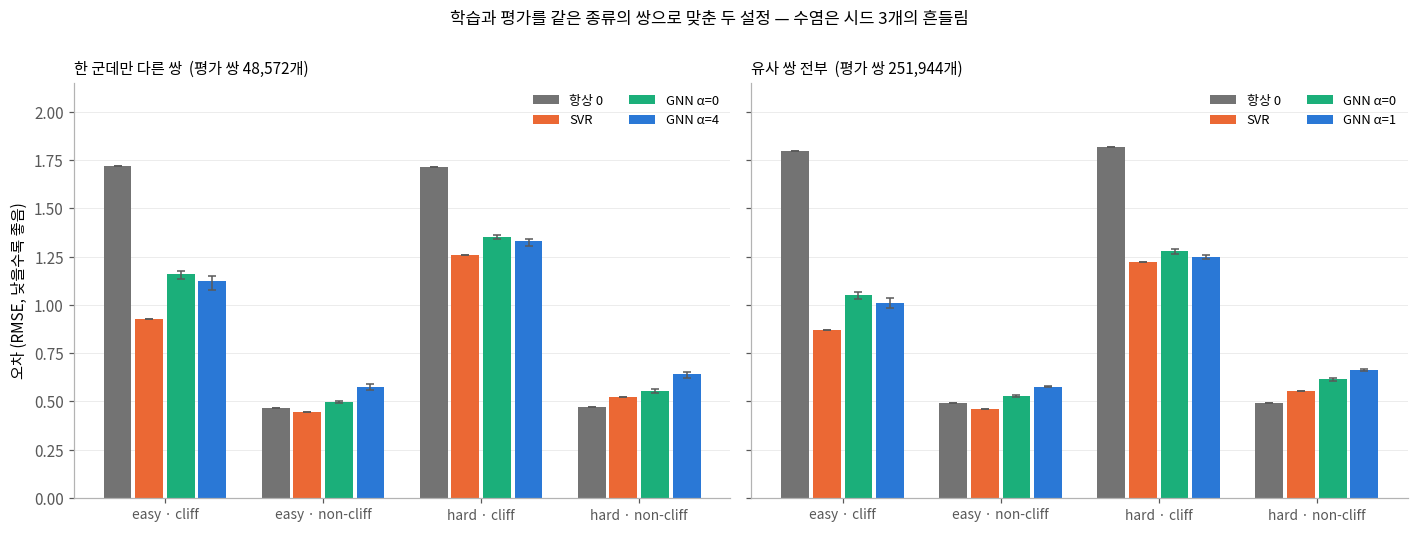

In [21]:
GROUPS = [('test_easy', True, 'easy · cliff'), ('test_easy', False, 'easy · non-cliff'),
          ('test_hard', True, 'hard · cliff'), ('test_hard', False, 'hard · non-cliff')]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for a_, (st, pset) in zip(axes, RESULTS.items()):
    bars = [('base', 'zero', MUTED, '항상 0'), ('base', 'svr', C2, 'SVR'),
            ('gnn', 0, C3, 'GNN α=0'), ('gnn', BEST[st], C1, f'GNN α={BEST[st]}')]
    w = 0.2
    for k_, (kind, key, col, lbl) in enumerate(bars):
        v, lo, hi = [], [], []
        for sp, cl, _ in GROUPS:
            d = pset[pset.split == sp]
            m = d.is_cliff if cl else ~d.is_cliff
            if kind == 'base':
                v.append(rmse(d[m][f'pred_{key}'], d[m].delta)); lo.append(0); hi.append(0)
            else:
                s = seed_rmse(d, key, m)
                v.append(s.mean()); lo.append(s.mean() - s.min()); hi.append(s.max() - s.mean())
        a_.bar(np.arange(4) + (k_ - 1.5) * w, v, w * 0.88, color=col, label=lbl, zorder=2,
               yerr=[lo, hi], capsize=2.5, error_kw=dict(elinewidth=1, ecolor='0.35'))
    a_.set(xticks=range(4), ylim=(0, 2.15))
    a_.set_xticklabels([g[2] for g in GROUPS], fontsize=9)
    a_.set_title(f'{LABEL[st]}  (평가 쌍 {len(pset[pset.split.str.startswith("test")]):,}개)', loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False, ncol=2)   # α가 설정마다 달라 패널마다 따로 단다
    a_.grid(axis='x', visible=False); tidy(a_)
axes[0].set_ylabel('오차 (RMSE, 낮을수록 좋음)')
fig.suptitle('학습과 평가를 같은 종류의 쌍으로 맞춘 두 설정 — 수염은 시드 3개의 흔들림', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

In [22]:
MODELS = ['zero', 'svr', 'gnn_a0', 'gnn_best']
display(pd.concat({LABEL[st]: pd.concat({m: rmse_table(pset, f'pred_{m}').loc[['test_easy', 'test_hard']]
                                         for m in MODELS}, axis=1)
                   for st, pset in RESULTS.items()}).round(3))
for st, pset in RESULTS.items():
    t_ = pset[pset.split.str.startswith('test')]
    d_ = rmse(t_.pred_gnn_best_fwd, t_.delta) - rmse(t_.pred_gnn_best, t_.delta)
    print(f'{LABEL[st]}: 양방향 평균 효과 {d_:+.3f} (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)')

zero                     svr                  gnn_a0  \
is_cliff              cliff non-cliff    all  cliff non-cliff    all  cliff   
           split                                                              
한 군데만 다른 쌍 test_easy  1.720     0.465  0.910  0.928     0.447  0.590  1.178   
           test_hard  1.715     0.470  0.880  1.256     0.524  0.734  1.356   
유사 쌍 전부    test_easy  1.796     0.490  1.034  0.872     0.459  0.603  1.049   
           test_hard  1.817     0.491  1.036  1.223     0.554  0.794  1.275   

                                      gnn_best                   
is_cliff             non-cliff    all    cliff non-cliff    all  
           split                                                 
한 군데만 다른 쌍 test_easy     0.498  0.709    1.138     0.590  0.748  
           test_hard     0.546  0.782    1.342     0.653  0.840  
유사 쌍 전부    test_easy     0.522  0.709    1.015     0.576  0.725  
           test_hard     0.608  0.844    1.241     0.662  0.859

한 군데만 다른 쌍: 양방향 평균 효과 +0.006 (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)
유사 쌍 전부: 양방향 평균 효과 +0.004 (거의 0 — 학습 때 이미 양방향을 보여줬기 때문)


### 학습 곡선

학습이 진행될수록 오차가 어떻게 줄었는지 본다. 두 선이 벌어질수록 외우기(과적합)가 심하다.

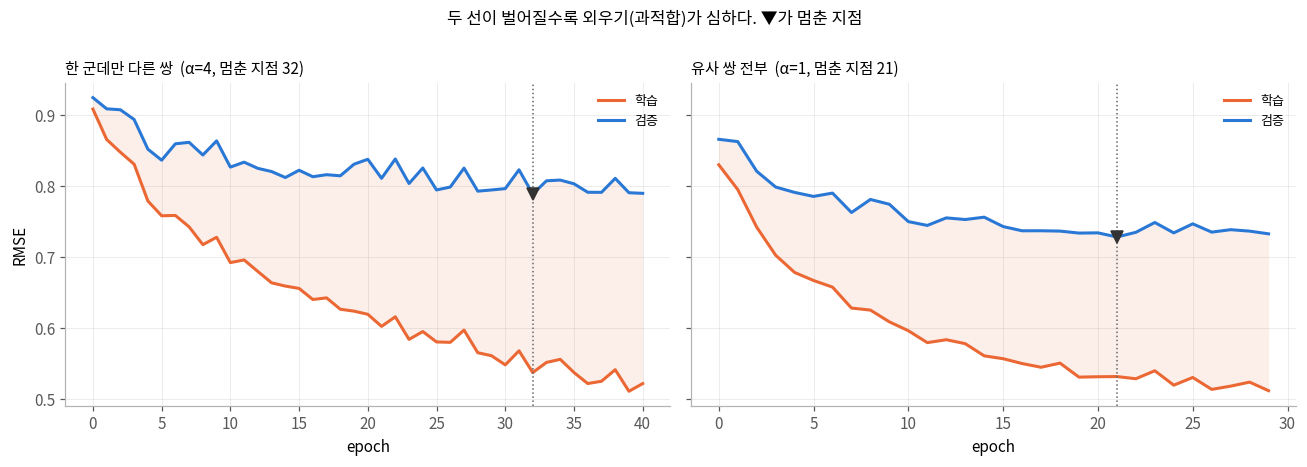

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a_, st in zip(axes, RESULTS):
    h = pd.read_csv(f'{RUNS}/hist_a{BEST[st]}_{TAGS[st]}_seed{SEEDS[0]}.csv')
    stop = int(h.best_epoch[0])
    a_.plot(h.epoch, h.train, color=C2, lw=2, label='학습')
    a_.plot(h.epoch, h.val, color=C1, lw=2, label='검증')
    a_.fill_between(h.epoch, h.train, h.val, color=C2, alpha=0.10, lw=0)
    a_.axvline(stop, color='0.4', lw=1, ls=':')
    a_.plot([stop], [h.val.min()], marker='v', color='0.2', ms=8, clip_on=False)
    a_.set(xlabel='epoch')
    a_.set_title(f'{LABEL[st]}  (α={BEST[st]}, 멈춘 지점 {stop})', loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False); tidy(a_)
axes[0].set_ylabel('RMSE')
fig.suptitle('두 선이 벌어질수록 외우기(과적합)가 심하다. ▼가 멈춘 지점', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### α에 따른 변화

α를 키우면 cliff는 좋아지고 non-cliff는 나빠진다. **왼쪽 아래가 좋다.**
점선 오른쪽은 "항상 0이라고 답하는 것"보다 못한 영역이다.

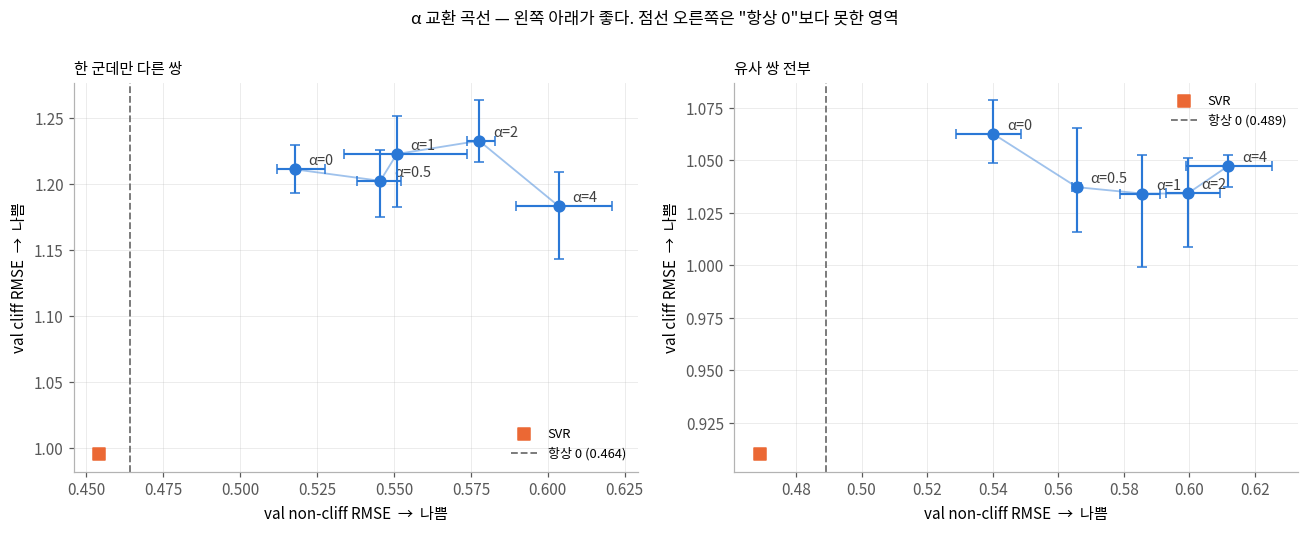

val cliff  val cliff 폭  val non-cliff  val all
           alpha                                                
한 군데만 다른 쌍 0          1.211        0.036          0.518    0.729
           0.5        1.202        0.051          0.546    0.742
           1          1.223        0.069          0.551    0.752
           2          1.233        0.047          0.578    0.771
           4          1.183        0.066          0.604    0.769
유사 쌍 전부    0          1.063        0.030          0.540    0.723
           0.5        1.037        0.049          0.566    0.727
           1          1.034        0.053          0.586    0.737
           2          1.034        0.043          0.600    0.745
           4          1.047        0.015          0.612    0.757

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for a_, (st, pset) in zip(axes, RESULTS.items()):
    v = pset[pset.split.str.startswith('val')]
    pts = []
    for a in ALPHAS:
        nc, cl = seed_rmse(v, a, ~v.is_cliff), seed_rmse(v, a, v.is_cliff)
        a_.errorbar(nc.mean(), cl.mean(),
                    xerr=[[nc.mean() - nc.min()], [nc.max() - nc.mean()]],
                    yerr=[[cl.mean() - cl.min()], [cl.max() - cl.mean()]],
                    fmt='o', ms=7, color=C1, ecolor=C1, elinewidth=1.4, capsize=3, zorder=3)
        a_.annotate(f'α={a}', (nc.mean(), cl.mean()), textcoords='offset points', xytext=(9, 3),
                    fontsize=9.5, color='0.25')
        pts.append((nc.mean(), cl.mean()))
    a_.plot(*zip(*sorted(pts)), color=C1, lw=1.2, alpha=.45, zorder=2)
    nm, cm = ~v.is_cliff, v.is_cliff
    a_.scatter([rmse(v[nm].pred_svr, v[nm].delta)], [rmse(v[cm].pred_svr, v[cm].delta)],
               marker='s', s=60, color=C2, zorder=4, label='SVR')
    z = rmse(v[nm].pred_zero, v[nm].delta)
    a_.axvline(z, color=MUTED, ls='--', lw=1.2, zorder=1, label=f'항상 0 ({z:.3f})')
    a_.set(xlabel='val non-cliff RMSE  →  나쁨', ylabel='val cliff RMSE  →  나쁨')
    a_.set_title(LABEL[st], loc='left', fontsize=10)
    a_.legend(fontsize=8.5, frameon=False); tidy(a_)
fig.suptitle('α 교환 곡선 — 왼쪽 아래가 좋다. 점선 오른쪽은 "항상 0"보다 못한 영역', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()
display(pd.concat({LABEL[st]: t for st, t in ALPHA_TABLES.items()}).round(3))

### 타깃별 차이

타깃별로 가장 어려운 경우(hard · cliff)의 오차를 비교한다.

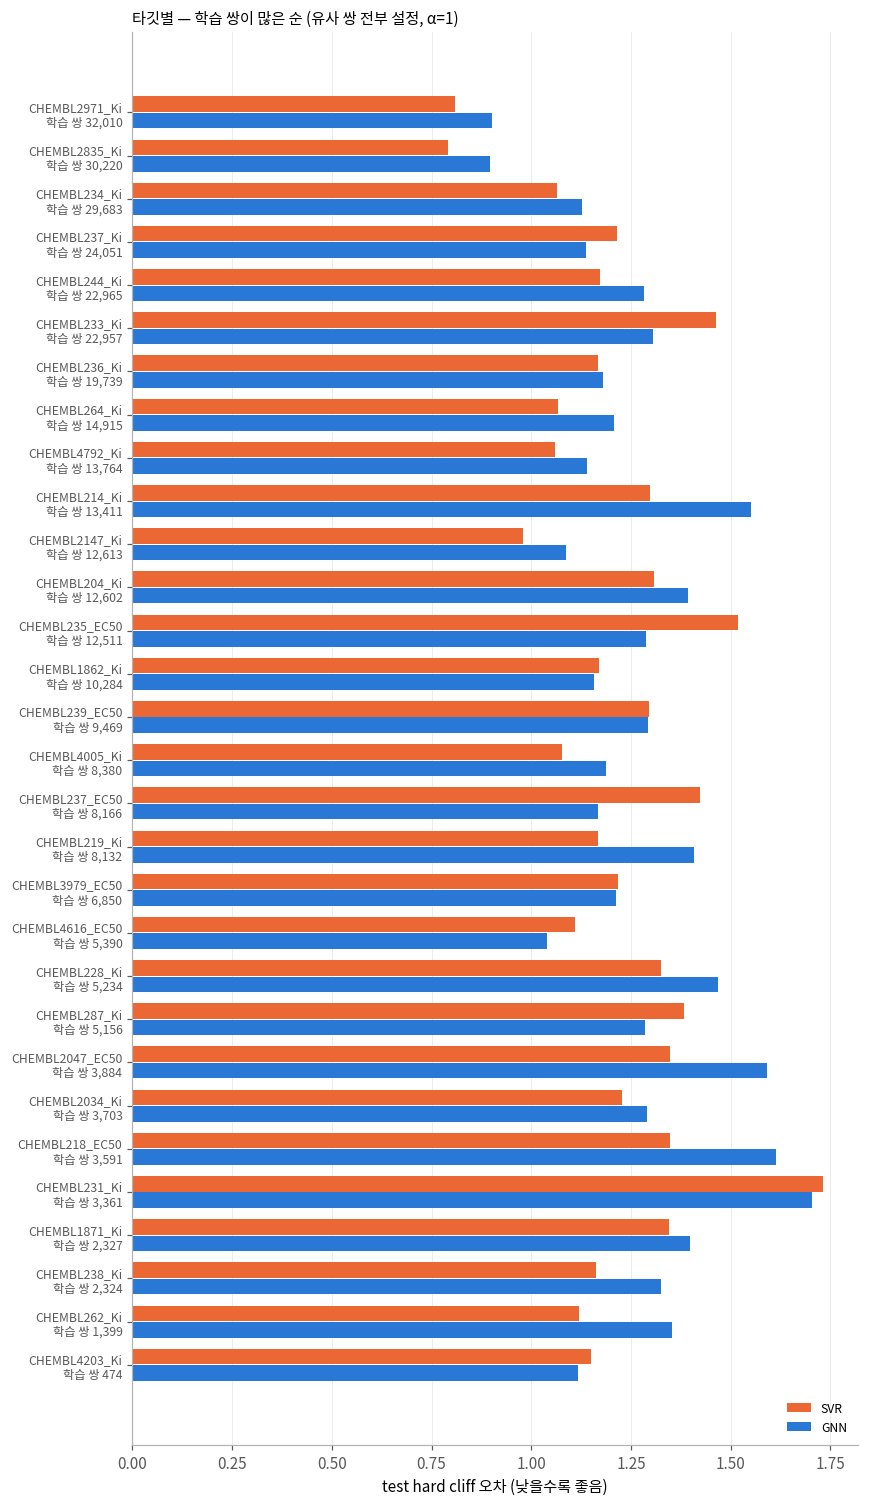

GNN이 SVR보다 나은 타깃: 11 / 30


In [25]:
pset = RESULTS['all']
hard = pset[(pset.split == 'test_hard') & pset.is_cliff]
per = pd.DataFrame({m: {t: rmse(d[f'pred_{m}'], d.delta) for t, d in hard.groupby('target')}
                    for m in ['svr', 'gnn_best']})
per['n_train'] = pset[pset.split == 'train'].target.value_counts()
per = per.sort_values('n_train')

fig, a_ = plt.subplots(figsize=(8, max(3.6, 0.42 * len(per) + 1.2)))
y, hgt = np.arange(len(per)), 0.36
a_.barh(y + hgt / 2 * 1.06, per.svr, hgt, color=C2, label='SVR', zorder=2)
a_.barh(y - hgt / 2 * 1.06, per.gnn_best, hgt, color=C1, label='GNN', zorder=2)
a_.set(yticks=y, xlabel='test hard cliff 오차 (낮을수록 좋음)')
a_.set_yticklabels([f'{t}\n학습 쌍 {n:,}' for t, n in zip(per.index, per.n_train)], fontsize=8)
a_.legend(fontsize=8, frameon=False, loc='lower right'); a_.grid(axis='y', visible=False); tidy(a_)
a_.set_title(f'타깃별 — 학습 쌍이 많은 순 (유사 쌍 전부 설정, α={BEST["all"]})', loc='left', fontsize=10)
fig.tight_layout(); plt.show()
print(f'GNN이 SVR보다 나은 타깃: {int((per.gnn_best < per.svr).sum())} / {len(per)}')

### 차이 크기별 오차

약효 차이가 작은 쌍 / 중간 / 큰 쌍으로 나눠 오차를 본다.

In [26]:
BUCKETS = ['|Δ|<1', '1≤|Δ|<2', '|Δ|≥2']
MAES = {}
for st, pset in RESULTS.items():
    t_ = pset[pset.split.str.startswith('test')]
    b = pd.cut(t_.delta.abs(), [0, 1, 2, np.inf], right=False, labels=BUCKETS)
    m = pd.concat({k: t_.assign(b=b, ae=(t_[f'pred_{k}'] - t_.delta).abs())
                      .groupby(['split', 'b'], observed=True).ae.mean() for k in MODELS}, axis=1)
    m.insert(0, 'n', t_.assign(b=b).groupby(['split', 'b'], observed=True).size())
    MAES[st] = m

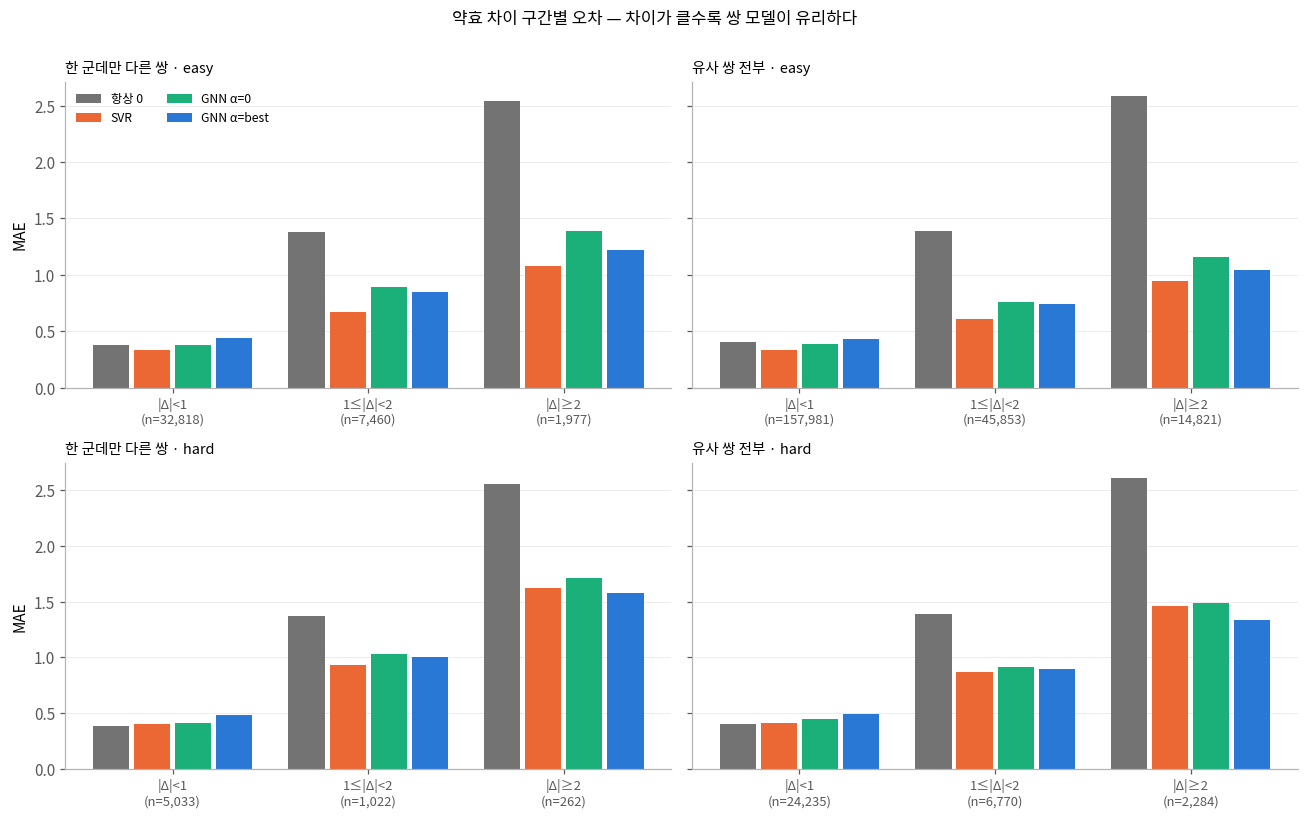

In [27]:
LBL = {'zero': '항상 0', 'svr': 'SVR', 'gnn_a0': 'GNN α=0', 'gnn_best': 'GNN α=best'}
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4), sharey='row')
for col, (st, mae) in enumerate(MAES.items()):
    for row, sp in enumerate(['test_easy', 'test_hard']):
        a_ = axes[row, col]
        w = 0.21
        for i, (m, c) in enumerate(zip(MODELS, [MUTED, C2, C3, C1])):
            v = [mae.loc[(sp, b), m] for b in BUCKETS]
            a_.bar(np.arange(3) + (i - 1.5) * w, v, w * 0.88, color=c, label=LBL[m], zorder=2)
        a_.set(xticks=range(3))
        a_.set_xticklabels([f'{b}\n(n={int(mae.loc[(sp, b), "n"]):,})' for b in BUCKETS], fontsize=8.5)
        a_.set_title(f'{LABEL[st]} · {"easy" if row == 0 else "hard"}', loc='left', fontsize=9.5)
        a_.grid(axis='x', visible=False); tidy(a_)
axes[0, 0].set_ylabel('MAE'); axes[1, 0].set_ylabel('MAE')
axes[0, 0].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle('약효 차이 구간별 오차 — 차이가 클수록 쌍 모델이 유리하다', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

### non-cliff에서 약한 이유

예측이 **실제보다 크게 나오는지** 본다. 차이가 거의 없는 쌍에도 큰 값을 말하면 오차가 커진다.
아래 숫자의 **기울기가 1보다 작으면 과장**이라는 뜻이다.

In [28]:
for st, pset in RESULTS.items():
    for sp in ['test_easy', 'test_hard']:
        d = pset[pset.split == sp]
        corr = float(np.corrcoef(d.pred_gnn_best, d.delta)[0, 1])
        slope = float(np.polyfit(d.pred_gnn_best, d.delta, 1)[0])
        print(f'{LABEL[st]:<10} {sp:<10} 상관 {corr:.3f}   기울기 {slope:.3f}')

    v = pset[pset.split.str.startswith('val')]
    c = float((v.delta * v.pred_gnn_best).sum() / (v.pred_gnn_best ** 2).sum())
    pset['pred_gnn_shrunk'] = c * pset.pred_gnn_best
    h = pset[pset.split == 'test_hard']
    b0 = rmse(h[h.is_cliff].pred_gnn_best, h[h.is_cliff].delta), rmse(h[~h.is_cliff].pred_gnn_best, h[~h.is_cliff].delta)
    a0 = rmse(h[h.is_cliff].pred_gnn_shrunk, h[h.is_cliff].delta), rmse(h[~h.is_cliff].pred_gnn_shrunk, h[~h.is_cliff].delta)
    print(f'  → 전체를 {c:.3f}배로 줄이면 cliff {b0[0]:.3f}→{a0[0]:.3f}, non-cliff {b0[1]:.3f}→{a0[1]:.3f}\n')

한 군데만 다른 쌍 test_easy  상관 0.608   기울기 0.741
한 군데만 다른 쌍 test_hard  상관 0.454   기울기 0.569
  → 전체를 0.696배로 줄이면 cliff 1.342→1.382, non-cliff 0.653→0.542

유사 쌍 전부    test_easy  상관 0.721   기울기 0.867


유사 쌍 전부    test_hard  상관 0.600   기울기 0.733
  → 전체를 0.849배로 줄이면 cliff 1.241→1.270, non-cliff 0.662→0.595



#### 아래 산점도 읽는 법

가로축 = **모델이 말한 차이**, 세로축 = **실제 차이**. 점 하나가 쌍 하나다.

| 보이는 것 | 뜻 |
|---|---|
| 회색 대각선 | 완벽한 예측 — 점이 이 선 위면 말한 대로 맞은 것 |
| **검은 선** | 점들에 실제로 맞춘 직선 |
| **검은 선이 대각선보다 누움** | **말한 것보다 실제가 작다 = 차이를 과장한다** |
| 회색 세로 띠 | 모델이 "거의 안 변한다"고 답한 구간 |
| 파란 점 / 주황 점 | 실제로 cliff인 쌍 / 아닌 쌍 |

#### 이번 결과 해석

**네 그림 모두 검은 선이 대각선보다 눕는다 — 모델이 차이를 과장한다.**

| | 기울기 | 모델이 "2"라고 하면 실제는 |
|---|---|---|
| 한 군데만 다른 쌍 · hard | 0.57 | 약 1.1 |
| 유사 쌍 전부 · hard | 0.73 | 약 1.5 |

학습과 평가를 같은 종류의 쌍으로 맞춘 **오른쪽이 대각선에 더 가깝다 — 과장이 덜하다.**
학습할 때 본 쌍과 평가받는 쌍의 성질이 어긋나 있던 것이 과장의 원인 중 하나였다는 뜻이다.

**주황 점이 가로로 넓게 퍼진 것**이 핵심 문제다. 실제로는 차이가 거의 없는데(세로로 0 근처)
모델이 크게 말한(가로로 멀리) 쌍들이고, **이게 non-cliff 오차의 대부분**이다.

그렇다고 예측 전체를 상수배로 줄이면 진짜 cliff까지 같이 줄어든다 — 위 숫자가 그 결과다.

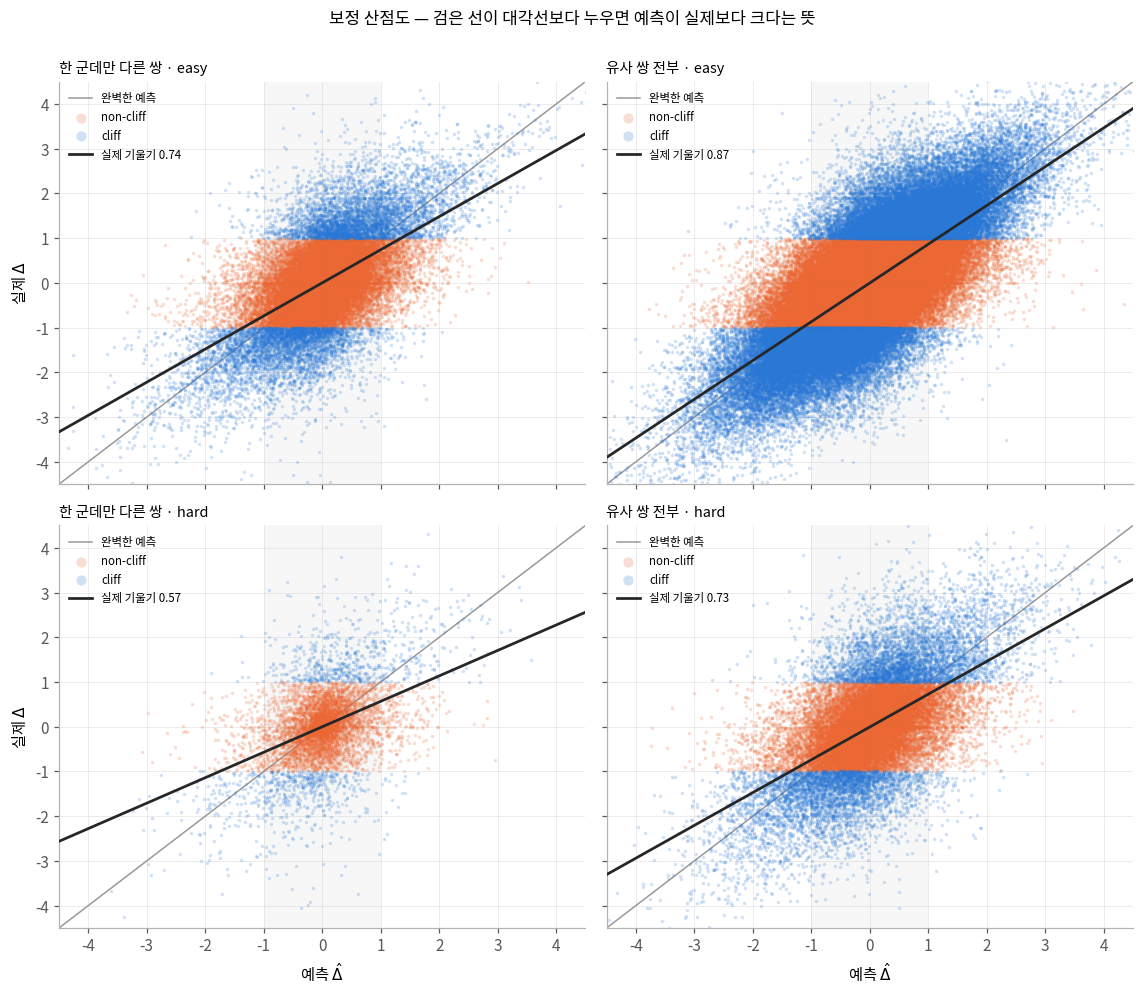

In [29]:
LIM = 4.5
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9), sharex=True, sharey=True)
for col, (st, pset) in enumerate(RESULTS.items()):
    for row, sp in enumerate(['test_easy', 'test_hard']):
        a_ = axes[row, col]
        d = pset[pset.split == sp]
        a_.plot([-LIM, LIM], [-LIM, LIM], color='0.6', lw=1, zorder=1, label='완벽한 예측')
        for cl, c, lbl in [(False, C2, 'non-cliff'), (True, C1, 'cliff')]:
            m = (d.is_cliff == cl).values
            a_.scatter(d.pred_gnn_best[m], d.delta[m], s=5, alpha=0.22, color=c, lw=0, zorder=2, label=lbl)
        sl, ic = np.polyfit(d.pred_gnn_best, d.delta, 1)
        xs = np.array([-LIM, LIM])
        a_.plot(xs, sl * xs + ic, color='0.15', lw=1.8, zorder=3, label=f'실제 기울기 {sl:.2f}')
        a_.axvspan(-1, 1, color='0.5', alpha=0.06, lw=0, zorder=0)
        a_.set(xlim=(-LIM, LIM), ylim=(-LIM, LIM))
        a_.set_title(f'{LABEL[st]} · {"easy" if row == 0 else "hard"}', loc='left', fontsize=9.5)
        a_.legend(fontsize=7.5, frameon=False, loc='upper left', markerscale=3)
        tidy(a_)
for a_ in axes[1]: a_.set_xlabel(r'예측 $\hat{\Delta}$')
for a_ in axes[:, 0]: a_.set_ylabel(r'실제 $\Delta$')
fig.suptitle(r'보정 산점도 — 검은 선이 대각선보다 누우면 예측이 실제보다 크다는 뜻', y=1.0, fontsize=11)
fig.tight_layout(); plt.show()

## 11. 결과 정리

**30개 타깃 · α 5가지 · 시드 3개**, 그리고 **학습과 평가의 난이도를 맞춘 두 설정**으로 돌렸다.

| 설정 | 학습 쌍 | 평가 쌍 |
|---|---|---|
| 한 군데만 다른 쌍 | 67,509 | 48,572 |
| 유사 쌍 전부 | 349,565 | 251,944 |

### 난이도를 맞추니 과장이 줄었다

| test hard | 상관 | 기울기 |
|---|---|---|
| 한 군데만 다른 쌍 | 0.454 | 0.569 |
| **유사 쌍 전부** | **0.600** | **0.733** |

학습할 때 본 쌍과 평가받는 쌍의 성질을 맞추자 **기울기가 0.57 → 0.73으로 올라갔다.**
예측을 과장하는 문제가 꽤 줄었다는 뜻이다. SVR과의 격차도 절반으로 좁혀졌다
(hard cliff, α=0 기준: 0.100 → 0.052).

### 잘 된 것
- **결과가 안정됐다.** 데이터가 적을 때는 같은 설정으로 다시 돌려도 결론이 뒤집혔는데,
  30개 타깃에서는 시드 흔들림이 작아져(0.006~0.073) 비교가 가능해졌다
- **cliff 가중치가 효과가 있다.** α를 키우면 cliff 오차가 줄고 non-cliff는 나빠진다.
  적당한 구간은 α = 1~2이고 α = 4는 양쪽 다 나빠진다
- **학습 데이터가 많을수록 낫다.** 평가가 더 어려워졌는데도 easy cliff 오차가 1.178 → 1.049로 줄었다
- **약효 차이가 아주 큰 쌍에서는 SVR보다 낫다**

### 아직 안 된 것
- **전체적으로는 SVR에 진다.** 두 설정 모두. 가장 가까운 hard cliff에서도 1.24 vs 1.22
- **차이가 작은 쌍에서는 "항상 0"보다도 못하다.** 어떤 α를 써도, 어떤 설정에서도 마찬가지다

### 원인
모델이 **약효 차이를 실제보다 크게 말한다.** 거의 안 바뀌는 쌍에도 큰 값을 내서 오차가 커진다.
예측 전체를 상수배로 줄이면 진짜 cliff까지 같이 나빠져서 해결이 안 된다.
**쌍마다 확신도를 다르게 주는 장치가 필요하다.**

### 다음 할 일
1. **cliff 판정 추가** — "이 쌍이 cliff인가"를 먼저 판단해서, 아닐 것 같으면 예측을 0 쪽으로 줄인다
2. **원자 기여도 시각화** — 모델이 어느 원자를 보고 판단했는지 그린다
3. **3D 입력** — 입체 구조와 전하 분포를 반영한다
